In [ ]:
%pip install scipy

Looking in indexes: https://artifactory.tcsbank.ru/artifactory/api/pypi/python-all/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 95.8 MB/s eta 0:00:00:00:0100:01

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python3.12 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import sys
import os
parent_dir = os.path.dirname(os.path.abspath('.'))
sys.path.append(parent_dir)

import pandas as pd
import numpy as np
# import seaborn as sns
import tinkoffpy as tf
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import ttest_ind

from mde_functions import *

import warnings
warnings.filterwarnings("ignore")

In [ ]:
tf.auth_by_credentials(username='e.zagoskin', password=password)

In [ ]:
gp = tf.Greenplum()

In [ ]:
QUERY = """
select *
from usr_deliv.cc_task_primary_56
where start_dt between '2025-12-28'::date - 56 - 98 + 2 and '2025-12-28'
"""
df_full = tf.gp_to_df(QUERY, gp_service='orig')

In [ ]:
QUERY = """
select *
from usr_deliv.cc_task_primary_pre_56
"""
df_pre = tf.gp_to_df(QUERY, gp_service='orig')

In [ ]:
days = 56
df_full['start_dt'] = pd.to_datetime(df_full['start_dt'])
df_pre['exp_start_dt'] = pd.to_datetime(df_pre['exp_start_dt'])
df_full['util'] = df_full['util'].astype(float)
df_full['success'] = df_full['success'].astype(float)
df3 = df_full.copy()
df_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118035 entries, 0 to 39344
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   region_id        118035 non-null  Int64         
 1   start_dt         118035 non-null  datetime64[ns]
 2   weekday          118035 non-null  Float64       
 3   util             118035 non-null  float64       
 4   success          118035 non-null  float64       
 5   meeting_cnt      118035 non-null  Int64         
 6   meeting_cnt_all  118035 non-null  Int64         
 7   workload         118035 non-null  Float64       
dtypes: Float64(2), Int64(3), datetime64[ns](1), float64(2)
memory usage: 8.7 MB


In [ ]:
len(df3), len(df3.groupby(['region_id']))

(118035, 572)

In [ ]:
df_full.head()

,region_id,start_dt,weekday,util,success,meeting_cnt,meeting_cnt_all,workload
0,18,2025-11-10,1.0,1.0,1.0,3,89,9.775281
1,10279,2025-11-29,6.0,7.0,8.0,19,191,1.60733
2,519,2025-10-23,4.0,1.0,2.0,2,29,4.965517
3,156,2025-12-01,1.0,12.0,18.0,38,330,8.036364
4,10354,2025-11-28,5.0,6.0,6.0,10,71,14.971831


In [ ]:
df_pre['util_rate_pre'] = df_pre['util_pre'] / df_pre['meeting_cnt_pre']
df_pre['success_rate_pre'] = df_pre['success_pre'] / df_pre['meeting_cnt_pre']
df_pre.head()

,region_id,exp_start_dt,weekday,util_pre,success_pre,meeting_cnt_pre,success_rate_pre_all,util_rate_pre,success_rate_pre
0,15002,2025-10-17,1.0,13.0,15.0,21.0,0.852843,0.619048,0.714286
1,136,2025-10-18,3.0,1.0,1.0,1.5,0.8,0.666667,0.666667
2,57,2025-10-20,5.0,22.5,26.0,40.0,0.746204,0.5625,0.65
3,9818,2025-10-29,3.0,1.0,1.5,2.0,0.754717,0.5,0.75
4,513,2025-10-11,4.0,11.0,12.0,20.0,0.688029,0.55,0.6


Ошибки 1 рода: 0.36%, 0.52%, 0.76%, 1.17%, 3.04% ||| 7.21%, 16.64%, 26.95%, 37.86%, 49.2%
0.65% uplift: 35.65%, 39.19%, 43.92%, 51.66%, 65.18% ||| 78.89%, 90.47%, 95.16%, 97.51%, 98.73%
0.7% uplift: 41.99%, 46.01%, 51.12%, 58.82%, 71.83% ||| 83.92%, 93.02%, 96.67%, 98.27%, 99.18%
0.75% uplift: 49.42%, 53.18%, 58.26%, 65.08%, 77.09% ||| 87.51%, 95.09%, 97.98%, 99.02%, 99.61%
0.8% uplift: 55.59%, 59.46%, 64.46%, 70.86%, 82.08% ||| 90.99%, 96.9%, 98.66%, 99.38%, 99.71%
0.85% uplift: 63.25%, 66.69%, 71.64%, 77.63%, 86.52% ||| 93.43%, 97.84%, 99.02%, 99.61%, 99.81%
0.9% uplift: 69.6%, 72.72%, 76.64%, 81.97%, 89.8% ||| 95.69%, 98.59%, 99.45%, 99.74%, 99.89%
0.95% uplift: 74.91%, 77.59%, 81.06%, 85.86%, 92.48% ||| 96.81%, 99.09%, 99.66%, 99.89%, 99.96%
1.0% uplift: 80.43%, 83.09%, 86.14%, 89.73%, 94.64% ||| 98.04%, 99.47%, 99.81%, 99.94%, 99.97%
1.05% uplift: 84.95%, 87.35%, 89.92%, 92.86%, 96.46% ||| 98.74%, 99.68%, 99.88%, 99.97%, 99.99%
1.1% uplift: 88.89%, 90.62%, 92.64%, 95.01%, 97.7% ||

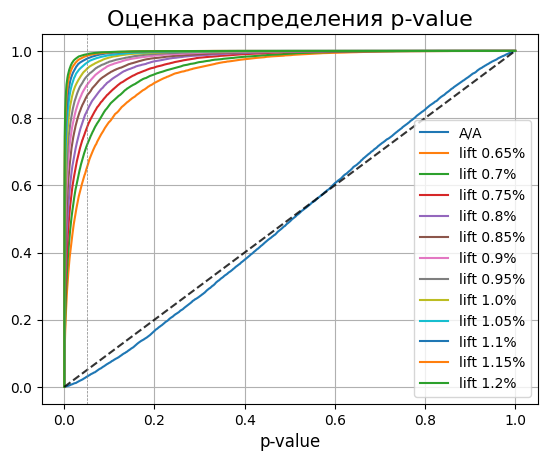

In [ ]:
global_list_1, legend_list_1 = switchback_cumped(result=df3, result_pre=df_pre, metric='util', unit='meeting_cnt', days=days
                                                 , effects=[1] + list(np.arange(1.0065, 1.012, 0.0005)), n_runs=10000
                                                 , additional_covariats=['meeting_cnt_all', 'workload','success_rate_pre_all','success_rate_pre'])
# CC utilization
# Test power for alpha in [0.01, 0.0125, 0.0167, 0.025, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]


Ошибки 1 рода: 0.29%, 0.36%, 0.54%, 1.0%, 2.56% ||| 6.54%, 15.91%, 26.42%, 37.96%, 49.71%
0.5% uplift: 30.86%, 34.17%, 39.37%, 47.06%, 61.51% ||| 76.51%, 89.27%, 94.76%, 97.38%, 98.69%
0.55% uplift: 38.24%, 42.26%, 47.84%, 55.21%, 69.12% ||| 82.03%, 92.39%, 96.41%, 98.3%, 99.26%
0.6% uplift: 47.09%, 51.12%, 56.76%, 64.32%, 76.56% ||| 87.61%, 95.36%, 97.98%, 99.04%, 99.52%
0.65% uplift: 56.38%, 60.38%, 65.21%, 72.34%, 83.11% ||| 91.83%, 97.01%, 98.64%, 99.46%, 99.79%
0.7% uplift: 63.87%, 67.5%, 72.23%, 78.66%, 87.91% ||| 94.55%, 98.29%, 99.42%, 99.84%, 99.96%
0.75% uplift: 72.04%, 75.23%, 79.24%, 84.34%, 91.65% ||| 96.59%, 99.01%, 99.66%, 99.95%, 99.99%
0.8% uplift: 78.35%, 81.3%, 84.43%, 88.91%, 94.38% ||| 97.81%, 99.42%, 99.83%, 99.94%, 99.99%
0.85% uplift: 84.82%, 87.12%, 89.5%, 92.71%, 96.54% ||| 98.78%, 99.79%, 99.94%, 99.98%, 99.99%
0.9% uplift: 89.3%, 91.01%, 93.22%, 95.52%, 98.0% ||| 99.39%, 99.84%, 99.95%, 99.98%, 99.99%
0.95% uplift: 93.01%, 94.29%, 95.72%, 97.31%, 98.96% |||

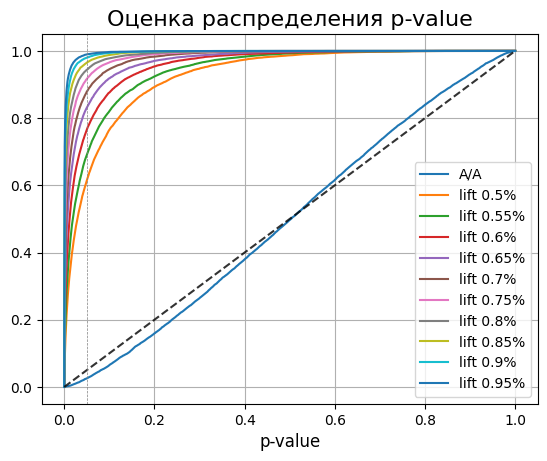

In [ ]:
global_list_2, legend_list_2 = switchback_cumped(result=df3, result_pre=df_pre, metric='success', unit='meeting_cnt', days=days
                                                 , effects=[1] + list(np.arange(1.005, 1.0095, 0.0005)), n_runs=10000
                                                 , additional_covariats=['meeting_cnt_all', 'workload','success_rate_pre_all','util_rate_pre'])
# CC success
# Test power for alpha in [0.01, 0.0125, 0.0167, 0.025, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]